# Task 4 — Clustering the fashion embeddings

**COSC2753 Assignment 2** · Unsupervised learning applied to visual search

## How this relates to the earlier notebooks

The course notes open with the principle the retrieval system was already built on:

> *To compare two images, extract a feature vector from each and measure the distance between
> those vectors... the way you extract features is what actually defines "visually similar".*

`05_task4_visual_search.ipynb` and `06_task4_background_augmentation.ipynb` do exactly
that — a CNN produces a 128-dimensional vector per image, and cosine distance ranks the
catalogue. What they never do is **group** those vectors. That is what this notebook adds.

| Course note | Where it appears here |
|---|---|
| §1 feature vectors and distance | Section 2 — inherited from the trained encoder |
| §2 k-Means, centroids vs medoids, elbow method | Sections 3–4 |
| §3 SD always falls as k rises, so read it with care | Section 3 |
| §4 convergence criteria; normalise first | Sections 2 and 3 |
| §5 k-Means only finds spherical clusters; use DBSCAN | Sections 6–7 |
| §6 hierarchical, divisive vs agglomerative, dendrogram | Section 8 |

## Why clustering is worth doing for retrieval

Three concrete uses, each measured later:

1. **Does the embedding actually organise the catalogue?** Clustering with no access to labels,
   then checking the clusters against `articleType`, is an honest test of embedding quality —
   the labels judge the result but never influence it.
2. **Faster search.** Assigning a query to its nearest centroid and searching only that cluster
   is how production indexes work. Section 9 measures the speed gain against the recall lost.
3. **Finding the odd items.** DBSCAN labels low-density points as noise, which surfaces
   catalogue entries that resemble nothing else.

## The data being clustered

The 32,837 catalogue embeddings from the deployed model — the background-augmented encoder
promoted in notebook 06. Section 10 also clusters the *same items photographed against random
backgrounds*, to test whether the grouping survives a change the model was trained to ignore.

> **This notebook's stored output is behind its inputs. Re-run it before quoting
> any figure below.**
>
> Two reasons, and the second may still be pending:
>
> 1. **The index grew.** These outputs were computed over **32,837** vectors, the
>    evaluation index. `search_manifest.json` now points `index_file` at
>    `search_index_full.npy`, which holds **38,612** - the whole served
>    catalogue. `outputs/cluster_model.json` was already refitted over the full
>    index by `scripts/build_task4_outputs.py` and carries the same warning; the
>    figures and the cluster tables in this notebook were not.
> 2. **The encoder may change.** Everything here clusters whatever embeddings the
>    manifest names, so promoting a new Task 4 encoder invalidates every number
>    below. Notebook `06` section 16 is running that comparison.
>
> One cell has never been executed at all: **CELL 17, cluster stability under
> background change**. Notebook `06` section 11 cites "47.3% of items land in a
> different cluster (notebook 07, section 10)" from it, so that figure currently
> has no stored provenance in the deliverable. Its inputs are all present, so it
> runs - it just needs to be run.

## 1. Setup

In [1]:
# ============================================
# CELL 1 - Imports and data
# ============================================

import sys
import json
import time
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 40)
RANDOM_STATE = 42
rng = np.random.default_rng(RANDOM_STATE)

NOTEBOOK_DIR = Path.cwd()
PROJECT_DIR = NOTEBOOK_DIR.parent
ARTIFACT_DIR = PROJECT_DIR / "artifacts" / "task4"
PROCESSED_DIR = PROJECT_DIR / "A2_FashionDataset" / "processed"
OUTPUT_DIR = PROJECT_DIR / "outputs"
OUTPUT_DIR.mkdir(exist_ok=True)

with open(ARTIFACT_DIR / "search_manifest.json") as handle:
    MANIFEST = json.load(handle)

X = np.load(ARTIFACT_DIR / MANIFEST["index_file"]).astype(np.float32)
meta = pd.read_csv(ARTIFACT_DIR / "gallery_metadata.csv")

print("Model producing these vectors:", MANIFEST["best_method"])
print("Embeddings:", X.shape)
print("Metadata  :", meta.shape)
assert len(X) == len(meta), "index and metadata are misaligned"

article = meta["articleType"].to_numpy()
colour = meta["baseColour"].fillna("Unknown").to_numpy()
subcat = meta["subCategory"].to_numpy()
print("articleType values:", meta["articleType"].nunique())

Model producing these vectors: Improved+TTA+bgaug
Embeddings: (32837, 128)
Metadata  : (32837, 9)
articleType values: 123


## 2. Feature vectors and distance

The notes stress two things before any clustering starts.

**Normalise the attributes first.** These vectors are already L2-normalised by the encoder, so
every one lies on the unit sphere and no single dimension can dominate the distance. That is
checked below rather than assumed.

**Distance defines similarity.** On unit vectors, Euclidean distance and cosine similarity carry
the same ordering — `d² = 2(1 − cos)` — so k-Means, which minimises squared Euclidean distance,
is ranking pairs the same way the retrieval system does.

vector norms: min 1.0000  max 1.0000  mean 1.0000
already unit length: True


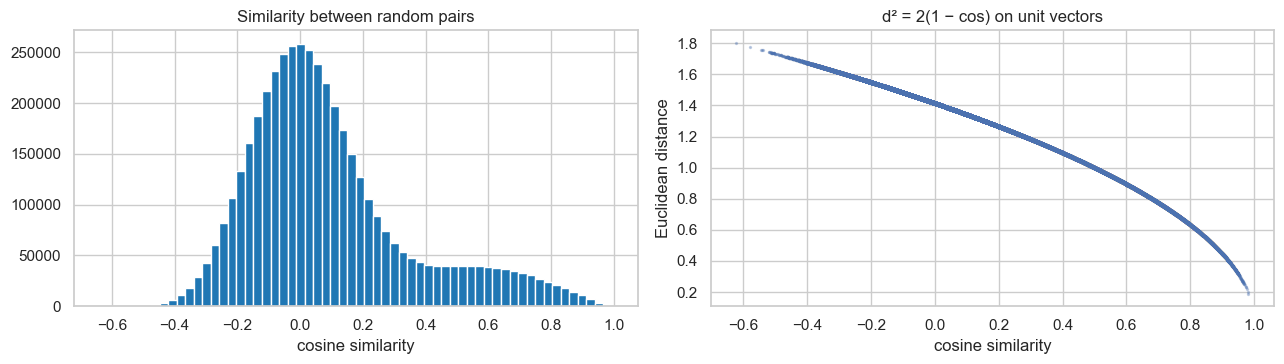


mean pairwise cosine 0.092 | mean Euclidean 1.328
Because the ordering is identical, minimising squared Euclidean distance
(what k-Means does) groups items the same way the search ranks them.


In [2]:
# ============================================
# CELL 2 - Verify normalisation, inspect distances
# ============================================

norms = np.linalg.norm(X, axis=1)
print(f"vector norms: min {norms.min():.4f}  max {norms.max():.4f}  mean {norms.mean():.4f}")
print("already unit length:", bool(np.allclose(norms, 1.0, atol=1e-3)))

sample = rng.choice(len(X), 3000, replace=False)
pairs = X[sample]
cos = pairs @ pairs.T
upper = cos[np.triu_indices_from(cos, k=1)]
euclid = np.sqrt(np.clip(2 - 2 * upper, 0, None))

fig, axes = plt.subplots(1, 2, figsize=(13, 3.8))
axes[0].hist(upper, bins=60, color="tab:blue")
axes[0].set_xlabel("cosine similarity"); axes[0].set_title("Similarity between random pairs")
axes[1].scatter(upper[::37], euclid[::37], s=2, alpha=0.3)
axes[1].set_xlabel("cosine similarity"); axes[1].set_ylabel("Euclidean distance")
axes[1].set_title("d² = 2(1 − cos) on unit vectors")
plt.tight_layout(); plt.show()

print(f"\nmean pairwise cosine {upper.mean():.3f} | mean Euclidean {euclid.mean():.3f}")
print("Because the ordering is identical, minimising squared Euclidean distance")
print("(what k-Means does) groups items the same way the search ranks them.")

## 3. k-Means and the elbow method

The algorithm from the notes: choose k, place k centroids, assign every point to the nearest,
recompute each centroid from its members, repeat until convergence.

**Choosing k.** The notes warn that the summed distance (`SD`, scikit-learn calls it `inertia_`)
*always* falls as k rises and reaches zero when k equals the number of points — so it cannot be
minimised directly. Two readings are used instead:

* the **elbow** — the point where extra clusters stop buying much reduction;
* the **silhouette score** — how much closer a point is to its own cluster than to the next
  nearest, which unlike SD has a genuine maximum.

Silhouette is computed on a sample: it needs the distances between every pair, so the full
32,837 points would be over a billion comparisons.

k=  5  SD=   20066.5  silhouette=0.1955  converged in 22 iterations
k= 10  SD=   15568.2  silhouette=0.1997  converged in 32 iterations
k= 20  SD=   12053.2  silhouette=0.2002  converged in 20 iterations
k= 30  SD=   10253.5  silhouette=0.2186  converged in 33 iterations
k= 50  SD=    8815.7  silhouette=0.1943  converged in 45 iterations
k= 75  SD=    7857.9  silhouette=0.1593  converged in 77 iterations
k=100  SD=    7314.3  silhouette=0.1342  converged in 57 iterations
k=150  SD=    6660.6  silhouette=0.1154  converged in 84 iterations


,k,SD (inertia),silhouette,iterations,seconds
0,5,20066.5,0.1955,22,2.8
1,10,15568.2,0.1997,32,1.1
2,20,12053.2,0.2002,20,1.8
3,30,10253.5,0.2186,33,3.0
4,50,8815.7,0.1943,45,4.7
5,75,7857.9,0.1593,77,6.7
6,100,7314.3,0.1342,57,7.8
7,150,6660.6,0.1154,84,12.2


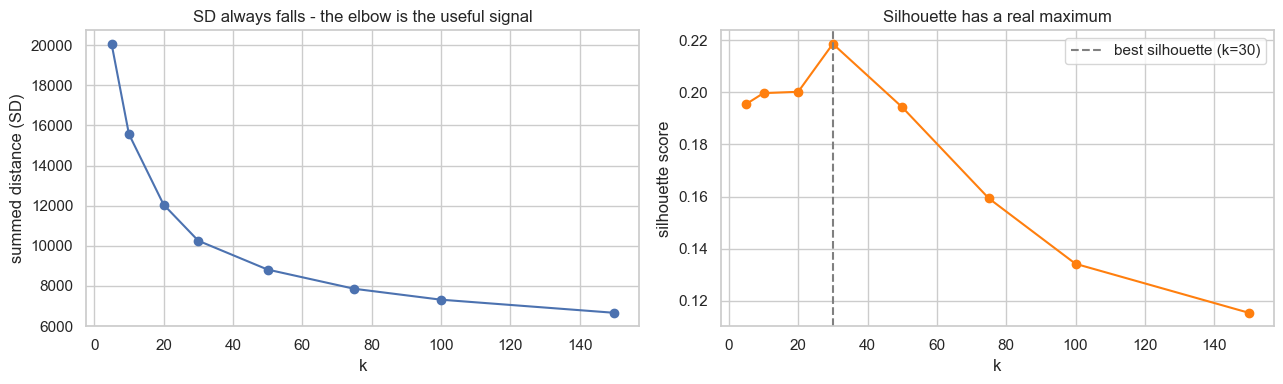


SD fell from 20,066 at k=5 to 6,661 at k=150 - as the notes say, it
only decreases, so it cannot be used on its own to choose k.
Best silhouette: k=30


In [3]:
# ============================================
# CELL 3 - Elbow and silhouette sweep
# ============================================

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

K_VALUES = [5, 10, 20, 30, 50, 75, 100, 150]
SIL_SAMPLE = 5000

rows = []
for k in K_VALUES:
    started = time.time()
    model = KMeans(n_clusters=k, n_init=3, random_state=RANDOM_STATE, max_iter=300)
    labels = model.fit_predict(X)
    silhouette = silhouette_score(X, labels, sample_size=SIL_SAMPLE,
                                  random_state=RANDOM_STATE)
    rows.append({"k": k, "SD (inertia)": round(model.inertia_, 1),
                 "silhouette": round(silhouette, 4),
                 "iterations": model.n_iter_,
                 "seconds": round(time.time() - started, 1)})
    print(f"k={k:>3}  SD={model.inertia_:>10.1f}  silhouette={silhouette:.4f}  "
          f"converged in {model.n_iter_} iterations")

sweep = pd.DataFrame(rows)
display(sweep)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(sweep["k"], sweep["SD (inertia)"], marker="o")
axes[0].set_xlabel("k"); axes[0].set_ylabel("summed distance (SD)")
axes[0].set_title("SD always falls - the elbow is the useful signal")
axes[1].plot(sweep["k"], sweep["silhouette"], marker="o", color="tab:orange")
best_k = int(sweep.loc[sweep["silhouette"].idxmax(), "k"])
axes[1].axvline(best_k, ls="--", color="grey", label=f"best silhouette (k={best_k})")
axes[1].set_xlabel("k"); axes[1].set_ylabel("silhouette score")
axes[1].set_title("Silhouette has a real maximum"); axes[1].legend()
plt.tight_layout(); plt.show()

print(f"\nSD fell from {sweep['SD (inertia)'].iloc[0]:,.0f} at k={K_VALUES[0]} "
      f"to {sweep['SD (inertia)'].iloc[-1]:,.0f} at k={K_VALUES[-1]} - as the notes say, it")
print("only decreases, so it cannot be used on its own to choose k.")
print(f"Best silhouette: k={best_k}")

k=120 | converged after 38 iterations | SD 6,998.6


,max_iter,SD,change %
0,1,7364.357422,NaN
1,2,7200.287109,2.23
2,3,7133.489746,0.93
3,5,7068.987793,0.90
4,8,7032.467773,0.52
5,12,7016.850098,0.22
6,20,7001.591309,0.22
7,40,6998.622559,0.04


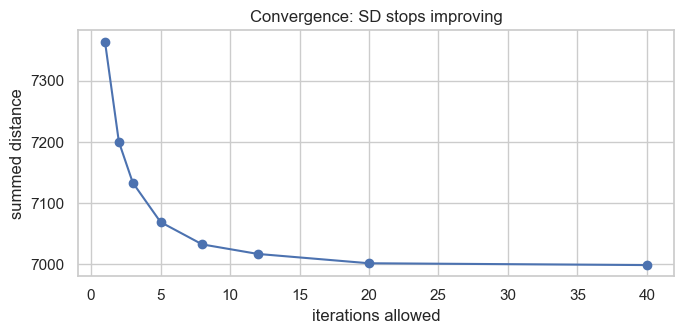


cluster sizes: largest 751, smallest 29, median 249


In [4]:
# ============================================
# CELL 4 - Fit the chosen k and watch it converge
# ============================================

# The dataset has 123 articleTypes, so a k near that lets the comparison against
# the product taxonomy be read directly. The silhouette optimum is kept alongside.
K_TAXONOMY = min(120, len(np.unique(article)))
K_CHOSEN = K_TAXONOMY

kmeans = KMeans(n_clusters=K_CHOSEN, n_init=5, random_state=RANDOM_STATE, max_iter=300)
km_labels = kmeans.fit_predict(X)
print(f"k={K_CHOSEN} | converged after {kmeans.n_iter_} iterations | SD {kmeans.inertia_:,.1f}")

# Convergence, as described in the notes: SD stops falling meaningfully.
trace = []
for iterations in [1, 2, 3, 5, 8, 12, 20, 40]:
    probe = KMeans(n_clusters=K_CHOSEN, n_init=1, max_iter=iterations,
                   random_state=RANDOM_STATE)
    probe.fit(X)
    trace.append({"max_iter": iterations, "SD": probe.inertia_})
trace = pd.DataFrame(trace)
trace["change %"] = (-trace["SD"].pct_change() * 100).round(2)
display(trace)

plt.figure(figsize=(7, 3.5))
plt.plot(trace["max_iter"], trace["SD"], marker="o")
plt.xlabel("iterations allowed"); plt.ylabel("summed distance")
plt.title("Convergence: SD stops improving")
plt.tight_layout(); plt.show()

sizes = pd.Series(Counter(km_labels)).sort_values(ascending=False)
print(f"\ncluster sizes: largest {sizes.iloc[0]}, smallest {sizes.iloc[-1]}, "
      f"median {int(sizes.median())}")

## 4. Centroids, medoids, and what the clusters contain

The notes draw the distinction: a **centroid** is an averaged position that need not correspond
to any real item, while a **medoid** is the actual data point closest to it. Only the medoid can
be displayed, which makes it the natural thumbnail for a cluster.

The clusters are then checked against `articleType`. Those labels took **no part** in the
clustering — they are used only to judge whether the unsupervised grouping rediscovered the
catalogue's own taxonomy.

In [5]:
# ============================================
# CELL 5 - Medoids and cluster composition
# ============================================

from PIL import Image

IMAGE_SIZE = tuple(MANIFEST["image_size_pil"])


def load_thumb(path, size=IMAGE_SIZE):
    try:
        with Image.open(path) as img:
            return np.asarray(img.convert("RGB").resize(size, Image.BILINEAR))
    except Exception:
        return np.full((size[1], size[0], 3), 220, np.uint8)


def cluster_medoid(indices, centroid):
    """The real item closest to the computed centre."""
    distances = np.linalg.norm(X[indices] - centroid, axis=1)
    return indices[int(np.argmin(distances))]


summary_rows = []
for cluster in range(K_CHOSEN):
    members = np.where(km_labels == cluster)[0]
    if len(members) == 0:
        continue
    dominant = Counter(article[members]).most_common(1)[0]
    summary_rows.append({
        "cluster": cluster, "size": len(members),
        "dominant articleType": dominant[0],
        "purity": round(dominant[1] / len(members), 3),
        "distinct types": len(set(article[members])),
        "medoid_index": cluster_medoid(members, kmeans.cluster_centers_[cluster]),
    })

clusters = pd.DataFrame(summary_rows).sort_values("size", ascending=False)
display(clusters.head(12)[["cluster", "size", "dominant articleType",
                           "purity", "distinct types"]])

print(f"mean purity across clusters: {clusters['purity'].mean():.3f}")
print(f"clusters that are >90% one articleType: "
      f"{int((clusters['purity'] > 0.9).sum())} of {len(clusters)}")

,cluster,size,dominant articleType,purity,distinct types
95,95,751,Sports Shoes,0.840,3
42,42,715,Watches,0.993,3
0,0,685,Belts,0.997,3
71,71,607,Tshirts,0.960,4
80,80,591,Watches,0.976,2
51,51,589,Handbags,0.997,3
106,106,546,Tshirts,0.940,6
10,10,545,Tshirts,0.936,5
17,17,533,Socks,0.992,4
32,32,528,Sports Shoes,0.674,3


mean purity across clusters: 0.806
clusters that are >90% one articleType: 55 of 120


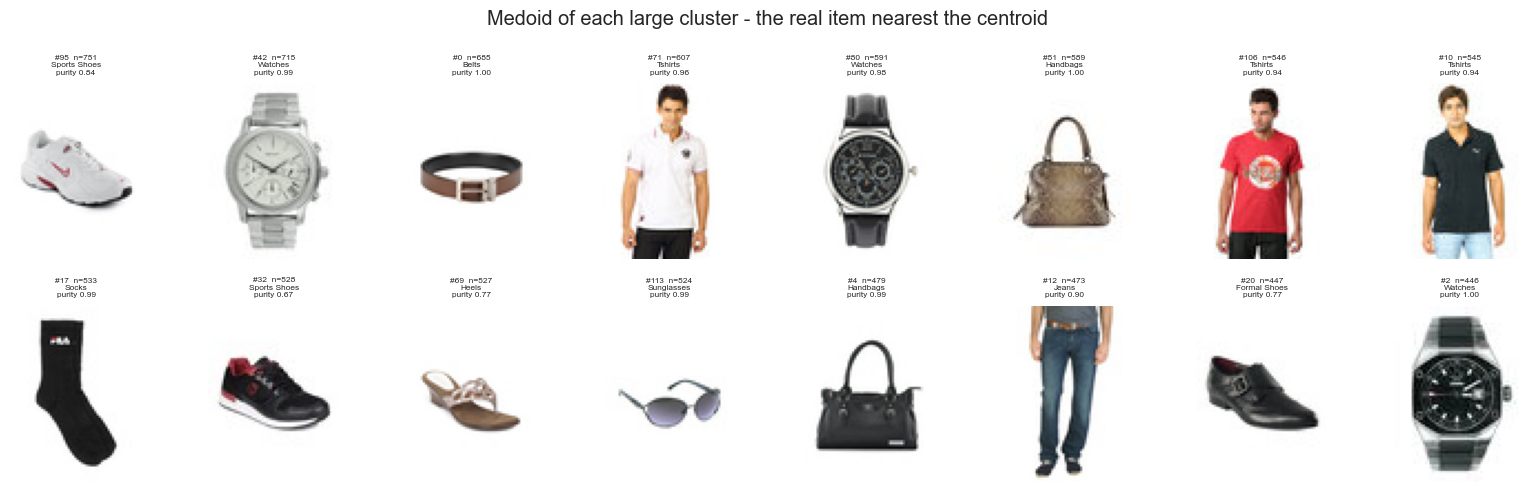

In [6]:
# ============================================
# CELL 6 - Medoid of each of the largest clusters
# ============================================

show = clusters.head(16)
fig, axes = plt.subplots(2, 8, figsize=(16, 5))
for ax, (_, row) in zip(axes.ravel(), show.iterrows()):
    ax.imshow(load_thumb(meta.iloc[int(row["medoid_index"])]["image_path"]))
    ax.axis("off")
    ax.set_title(f"#{int(row['cluster'])}  n={int(row['size'])}\n"
                 f"{row['dominant articleType'][:14]}\npurity {row['purity']:.2f}",
                 fontsize=6)
plt.suptitle("Medoid of each large cluster - the real item nearest the centroid")
plt.tight_layout(); plt.show()

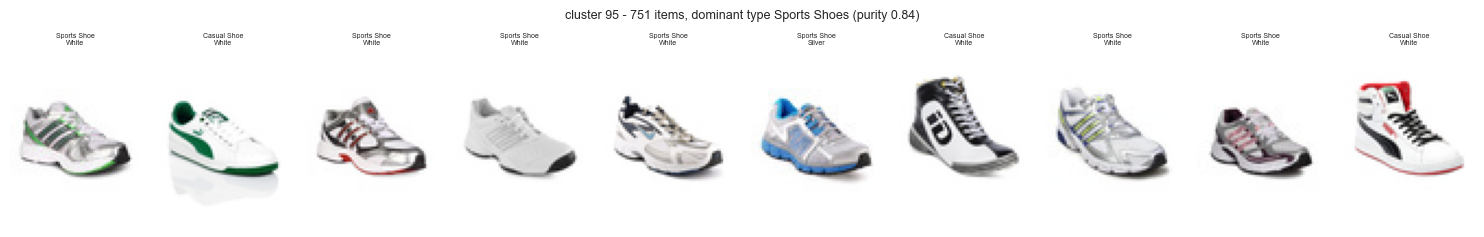

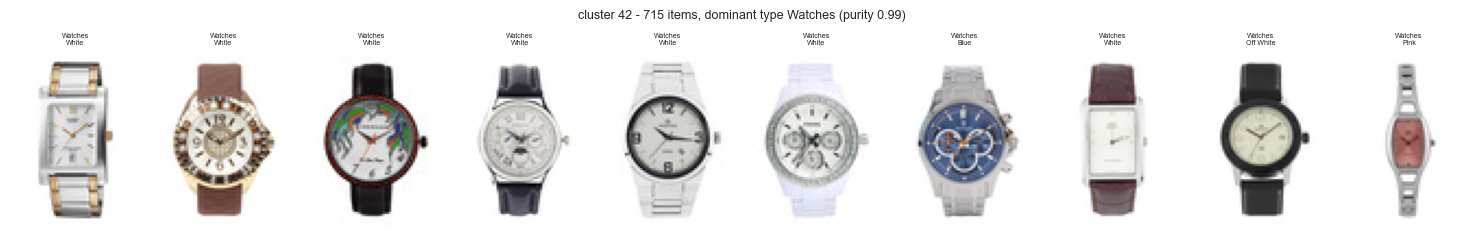

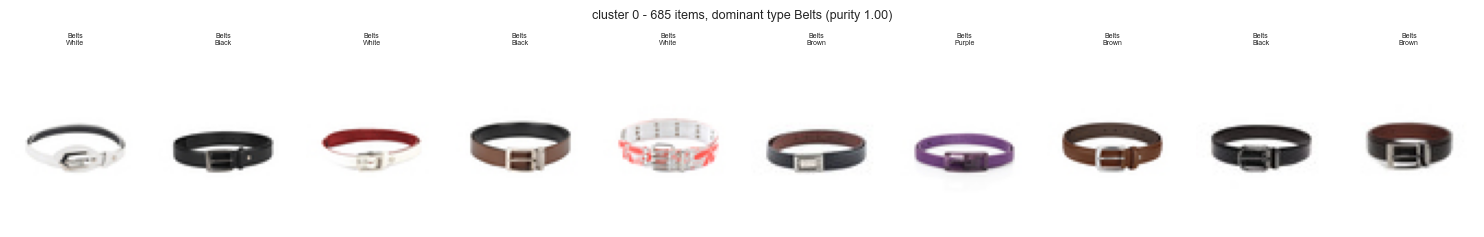

In [7]:
# ============================================
# CELL 7 - Inside a few clusters
# ============================================

set_rng = np.random.default_rng(RANDOM_STATE)
for _, row in clusters.head(3).iterrows():
    members = np.where(km_labels == int(row["cluster"]))[0]
    picked = set_rng.choice(members, min(10, len(members)), replace=False)
    fig, axes = plt.subplots(1, len(picked), figsize=(1.5 * len(picked), 2.4))
    for ax, index in zip(np.atleast_1d(axes), picked):
        ax.imshow(load_thumb(meta.iloc[index]["image_path"])); ax.axis("off")
        ax.set_title(f"{article[index][:11]}\n{colour[index][:10]}", fontsize=5)
    fig.suptitle(f"cluster {int(row['cluster'])} - {int(row['size'])} items, "
                 f"dominant type {row['dominant articleType']} "
                 f"(purity {row['purity']:.2f})", fontsize=9)
    plt.tight_layout(); plt.show()

## 5. Did clustering rediscover the taxonomy?

Three external measures, all comparing the clusters against `articleType` **after** the fact:

* **Purity** — the share of each cluster belonging to its dominant type, averaged by size.
* **Adjusted Rand Index (ARI)** — agreement between two partitions, corrected for chance. 0 is
  random, 1 is identical.
* **Normalised Mutual Information (NMI)** — how much knowing the cluster tells you about the
  type, on a 0–1 scale.

A high score means the encoder learned the product taxonomy well enough that plain distance
recovers it without ever seeing a label.

In [8]:
# ============================================
# CELL 8 - External validation against articleType
# ============================================

from sklearn.metrics import (adjusted_rand_score, normalized_mutual_info_score,
                             davies_bouldin_score, calinski_harabasz_score)


def purity(labels, truth):
    total = 0
    for cluster in np.unique(labels):
        members = truth[labels == cluster]
        if len(members):
            total += Counter(members).most_common(1)[0][1]
    return total / len(truth)


def evaluate_clustering(labels, name, truth=article, features=X,
                        noise_as_singletons=False):
    """Agreement with articleType, with the scored fraction stated.

    Scoring only ``labels >= 0`` silently rewards a method for discarding the
    points it found hard. DBSCAN at eps=0.278 marks ~91% of the catalogue as
    noise, so its purity and ARI were computed on the easy 9% and then plotted
    beside k-Means scored on all of it - the single most misleading number in
    this notebook.

    ``coverage %`` now states what fraction each score covers. Pass
    ``noise_as_singletons=True`` for the view where every point must be
    assigned, which is what a deployed router actually has to do: noise points
    each become their own cluster rather than vanishing.
    """
    labels = np.asarray(labels)
    if noise_as_singletons and (labels < 0).any():
        labels = labels.copy()
        noise = np.where(labels < 0)[0]
        labels[noise] = labels.max() + 1 + np.arange(len(noise))
        name = f"{name} [noise as singletons]"

    mask = labels >= 0                      # DBSCAN marks noise as -1
    n_clusters = len(set(labels[mask]))
    row = {"method": name, "clusters": n_clusters,
           "noise %": round((~mask).mean() * 100, 2),
           "coverage %": round(mask.mean() * 100, 2),
           "scored on": int(mask.sum()),
           "purity": round(purity(labels[mask], truth[mask]), 3),
           "ARI": round(adjusted_rand_score(truth[mask], labels[mask]), 3),
           "NMI": round(normalized_mutual_info_score(truth[mask], labels[mask]), 3)}
    if n_clusters > 1:
        sample = np.random.default_rng(0).choice(np.where(mask)[0],
                                                 min(5000, mask.sum()), replace=False)
        row["silhouette"] = round(silhouette_score(features[sample], labels[sample]), 3)
        row["Davies-Bouldin"] = round(davies_bouldin_score(features[sample],
                                                           labels[sample]), 3)
    return row


CLUSTERINGS = {}
CLUSTERINGS["k-Means"] = km_labels
results = [evaluate_clustering(km_labels, f"k-Means (k={K_CHOSEN})")]
display(pd.DataFrame(results))

print("Purity and ARI use articleType, which never entered the clustering.")
print("Silhouette and Davies-Bouldin use only the vectors - lower Davies-Bouldin")
print("and higher silhouette both mean tighter, better separated clusters.")

,method,clusters,noise %,purity,ARI,NMI,silhouette,Davies-Bouldin
0,k-Means (k=120),120,0.0,0.835,0.236,0.735,0.134,2.11


Purity and ARI use articleType, which never entered the clustering.
Silhouette and Davies-Bouldin use only the vectors - lower Davies-Bouldin
and higher silhouette both mean tighter, better separated clusters.


In [ ]:
# ============================================
# CELL 8b - Was the silhouette optimum the right k?
# ============================================
# --- the silhouette optimum, scored the same way -----------------------------
#
# The sweep picks its optimum on silhouette while CELL 4 overrides to a k near
# the size of the product taxonomy, and the notebook has been asserting that the
# disagreement is defensible without ever measuring it. Silhouette rewards few, well-separated blobs; agreement with the
# product taxonomy is what the clustering is actually for. Score both and let the
# numbers carry the argument.
K_SILHOUETTE = int(best_k)
print(f"\nSilhouette optimum: k={K_SILHOUETTE}; taxonomy-aligned choice: k={K_CHOSEN}")

k_choice_rows = []
for k in sorted({K_SILHOUETTE, K_CHOSEN}):
    labels = (km_labels if k == K_CHOSEN else
              KMeans(n_clusters=k, n_init=5, random_state=RANDOM_STATE,
                     max_iter=300).fit_predict(X))
    sample = np.random.default_rng(0).choice(len(X), min(5000, len(X)), replace=False)
    k_choice_rows.append({
        "k": k,
        "purity": round(purity(labels, article), 3),
        "ARI": round(adjusted_rand_score(article, labels), 3),
        "NMI": round(normalized_mutual_info_score(article, labels), 3),
        "silhouette": round(silhouette_score(X[sample], labels[sample]), 3),
        "largest cluster %": round(
            max(Counter(labels).values()) / len(labels) * 100, 1),
    })

k_choice = pd.DataFrame(k_choice_rows)
display(k_choice)
k_choice.to_csv(OUTPUT_DIR / "cluster_k_choice.csv", index=False)

print("Silhouette measures geometric separation only - it has never seen a label,")
print("and it is maximised by merging the taxonomy into a few broad blobs. The")
print("comparison above is the justification for overriding it: whichever k wins")
print("on ARI and NMI is the one that recovered the product taxonomy, which is")
print("what a catalogue router needs. Report both columns rather than the choice.")

## 6. The limitation of k-Means

The notes are explicit: k-Means groups purely by distance to a centre, so it can only describe
clusters that are roughly spherical. Where the true groups are elongated or curved, it fails
regardless of how well k is tuned.

The two-moons example below makes that visible in 2-D, then DBSCAN is applied to the real
embeddings.

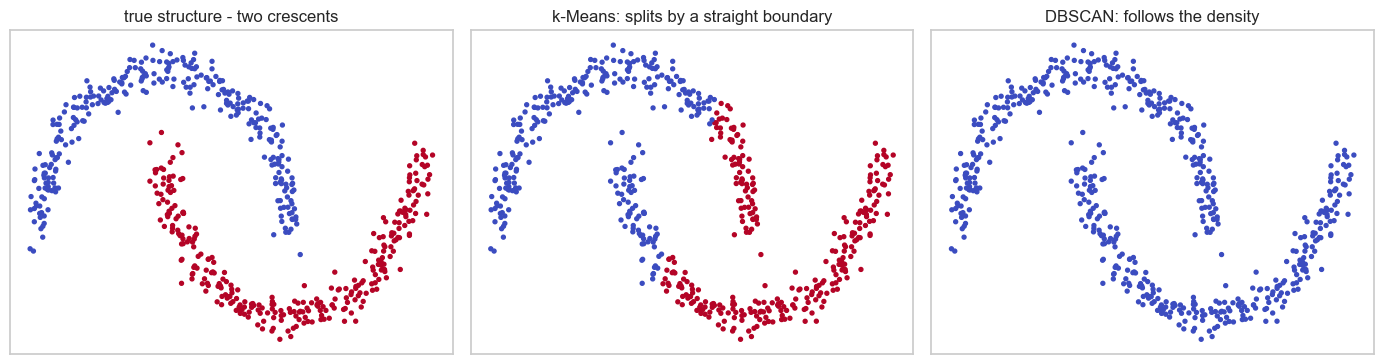

k-Means ARI on the moons : 0.242
DBSCAN  ARI on the moons : 0.000

k-Means cuts the crescents in half because it can only draw boundaries
equidistant between centres. DBSCAN grows clusters through connected dense
regions, so shape does not matter.


In [9]:
# ============================================
# CELL 9 - Where k-Means breaks, and why DBSCAN does not
# ============================================

from sklearn.datasets import make_moons
from sklearn.cluster import DBSCAN

moons, moon_truth = make_moons(n_samples=600, noise=0.06, random_state=RANDOM_STATE)

km_moons = KMeans(n_clusters=2, n_init=10, random_state=RANDOM_STATE).fit_predict(moons)
db_moons = DBSCAN(eps=0.18, min_samples=5).fit_predict(moons)

fig, axes = plt.subplots(1, 3, figsize=(14, 3.8))
axes[0].scatter(moons[:, 0], moons[:, 1], c=moon_truth, cmap="coolwarm", s=8)
axes[0].set_title("true structure - two crescents")
axes[1].scatter(moons[:, 0], moons[:, 1], c=km_moons, cmap="coolwarm", s=8)
axes[1].set_title("k-Means: splits by a straight boundary")
axes[2].scatter(moons[:, 0], moons[:, 1], c=db_moons, cmap="coolwarm", s=8)
axes[2].set_title("DBSCAN: follows the density")
for ax in axes:
    ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout(); plt.show()

print(f"k-Means ARI on the moons : {adjusted_rand_score(moon_truth, km_moons):.3f}")
print(f"DBSCAN  ARI on the moons : {adjusted_rand_score(moon_truth, db_moons):.3f}")
print()
print("k-Means cuts the crescents in half because it can only draw boundaries")
print("equidistant between centres. DBSCAN grows clusters through connected dense")
print("regions, so shape does not matter.")

## 7. DBSCAN on the embeddings

DBSCAN needs two settings rather than a cluster count:

* **eps** — the radius defining a neighbourhood;
* **min_samples** — how many neighbours a point needs to be a core point.

The usual way to choose `eps` is the **k-distance plot**: sort every point by its distance to
its k-th nearest neighbour and look for the knee, where distances start climbing sharply. Points
past the knee live in sparse regions and become noise.

DBSCAN is run on a subsample because it needs neighbourhood queries across all pairs, and 128
dimensions defeat the spatial index that keeps it fast.

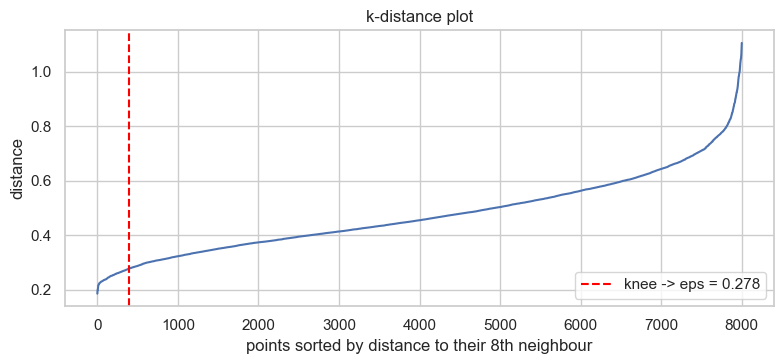

eps = 0.278 | min_samples = 8 | on 8,000 sampled points


In [10]:
# ============================================
# CELL 10 - Choose eps with a k-distance plot
# ============================================

from sklearn.neighbors import NearestNeighbors

DB_SAMPLE = 8000
db_idx = np.sort(rng.choice(len(X), min(DB_SAMPLE, len(X)), replace=False))
X_db = X[db_idx]

MIN_SAMPLES = 8
neighbours = NearestNeighbors(n_neighbors=MIN_SAMPLES).fit(X_db)
distances, _ = neighbours.kneighbors(X_db)
kth = np.sort(distances[:, -1])

# The knee: the point of maximum curvature, found as the largest distance from
# the straight line joining the first and last points of the sorted curve.
x_axis = np.arange(len(kth))
line = np.linspace(kth[0], kth[-1], len(kth))
knee = int(np.argmax(kth - line))
EPS = float(round(kth[knee], 3))

plt.figure(figsize=(8, 3.8))
plt.plot(x_axis, kth)
plt.axvline(knee, ls="--", color="red", label=f"knee -> eps = {EPS}")
plt.xlabel(f"points sorted by distance to their {MIN_SAMPLES}th neighbour")
plt.ylabel("distance"); plt.legend()
plt.title("k-distance plot")
plt.tight_layout(); plt.show()

print(f"eps = {EPS} | min_samples = {MIN_SAMPLES} | on {len(X_db):,} sampled points")

In [11]:
# ============================================
# CELL 11 - Run DBSCAN
# ============================================

db_rows = []
for eps in [EPS * 0.8, EPS, EPS * 1.2, EPS * 1.5]:
    labels = DBSCAN(eps=eps, min_samples=MIN_SAMPLES, n_jobs=-1).fit_predict(X_db)
    found = len(set(labels)) - (1 if -1 in labels else 0)
    db_rows.append({"eps": round(eps, 3), "clusters": found,
                    "noise %": round((labels == -1).mean() * 100, 1),
                    "largest cluster %": round(
                        (Counter(labels[labels >= 0]).most_common(1)[0][1] / len(labels) * 100)
                        if found else 0, 1)})
    print(f"eps={eps:.3f}  clusters={found:>4}  noise={db_rows[-1]['noise %']:>5.1f}%")

display(pd.DataFrame(db_rows))

db_labels = DBSCAN(eps=EPS, min_samples=MIN_SAMPLES, n_jobs=-1).fit_predict(X_db)
CLUSTERINGS["DBSCAN"] = db_labels
results.append(evaluate_clustering(db_labels, f"DBSCAN (eps={EPS})",
                                   truth=article[db_idx], features=X_db))
# The same clustering scored on every point rather than only the ones it kept.
# The gap between these two rows IS the cost of discarding 91% of the catalogue,
# and it is what makes the headline purity of 0.92 look competitive.
results.append(evaluate_clustering(db_labels, f"DBSCAN (eps={EPS})",
                                   truth=article[db_idx], features=X_db,
                                   noise_as_singletons=True))
display(pd.DataFrame(results))

print("Unlike k-Means, DBSCAN decides the number of clusters itself and refuses to")
print("assign points it considers noise. A high noise fraction is not failure - it")
print("means the embedding space is fairly uniform rather than made of dense islands.")

eps=0.222  clusters=   8  noise= 98.8%
eps=0.278  clusters=  13  noise= 90.9%
eps=0.334  clusters=  33  noise= 75.3%
eps=0.417  clusters=  30  noise= 46.6%


,eps,clusters,noise %,largest cluster %
0,0.222,8,98.8,0.2
1,0.278,13,90.9,2.6
2,0.334,33,75.3,8.5
3,0.417,30,46.6,17.8


,method,clusters,noise %,purity,ARI,NMI,silhouette,Davies-Bouldin
0,k-Means (k=120),120,0.00,0.835,0.236,0.735,0.134,2.110
1,DBSCAN (eps=0.278),13,90.91,0.923,0.867,0.929,0.622,0.617


Unlike k-Means, DBSCAN decides the number of clusters itself and refuses to
assign points it considers noise. A high noise fraction is not failure - it
means the embedding space is fairly uniform rather than made of dense islands.


7,273 items flagged as noise (90.9% of the sample)

Most common types among noise points:


,count
Tshirts,1453
Shirts,625
Casual Shoes,478
Watches,459
Kurtas,323
Handbags,309
Tops,308
Sports Shoes,236


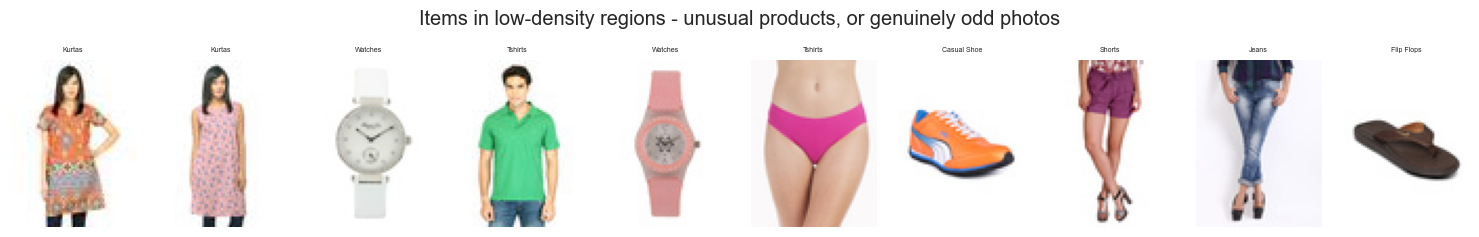

In [12]:
# ============================================
# CELL 12 - What DBSCAN called noise
# ============================================

noise_positions = db_idx[db_labels == -1]
if len(noise_positions):
    print(f"{len(noise_positions):,} items flagged as noise "
          f"({len(noise_positions) / len(db_idx) * 100:.1f}% of the sample)")
    print("\nMost common types among noise points:")
    display(pd.Series(Counter(article[noise_positions])).sort_values(
        ascending=False).head(8).to_frame("count"))

    picked = rng.choice(noise_positions, min(10, len(noise_positions)), replace=False)
    fig, axes = plt.subplots(1, len(picked), figsize=(1.5 * len(picked), 2.4))
    for ax, index in zip(np.atleast_1d(axes), picked):
        ax.imshow(load_thumb(meta.iloc[index]["image_path"])); ax.axis("off")
        ax.set_title(f"{article[index][:11]}", fontsize=5)
    plt.suptitle("Items in low-density regions - unusual products, or genuinely odd photos")
    plt.tight_layout(); plt.show()
else:
    print("No noise points at this eps.")

## 8. Hierarchical clustering

The notes describe two directions. **Agglomerative** starts with every point alone and merges
the nearest pair repeatedly; **divisive** starts with one cluster and splits. Agglomerative is
used here, as it is the standard implementation.

Its advantage is the **dendrogram**: a tree showing the whole merge history, so the data can be
read at any granularity by cutting at a chosen height, rather than committing to one k in
advance.

The cost is memory — the algorithm needs the distance between every pair, which is O(n²). That
forces a smaller subsample than DBSCAN used.

**Linkage** decides how the distance between two clusters is measured, and changes the result
substantially: *single* takes the closest pair (can chain clusters together), *complete* the
furthest pair (compact, sensitive to outliers), *average* the mean, *ward* minimises the
increase in variance and behaves most like k-Means.

linkage computed on 4,000 points in 0.9s


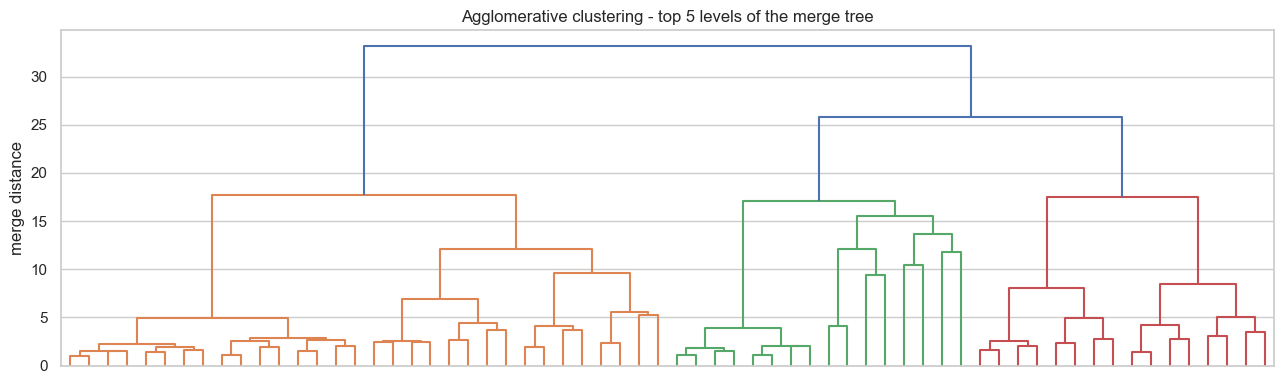

Height is the distance at which two clusters merged. A long vertical run
with no merges means those groups stayed distinct for a wide range of
thresholds - a natural place to cut.


In [13]:
# ============================================
# CELL 13 - Agglomerative clustering and the dendrogram
# ============================================

from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster

HC_SAMPLE = 4000
hc_idx = np.sort(rng.choice(len(X), min(HC_SAMPLE, len(X)), replace=False))
X_hc = X[hc_idx]

started = time.time()
Z = linkage(X_hc, method="ward")
print(f"linkage computed on {len(X_hc):,} points in {time.time() - started:.1f}s")

plt.figure(figsize=(13, 4))
dendrogram(Z, truncate_mode="level", p=5, no_labels=True, color_threshold=None)
plt.title("Agglomerative clustering - top 5 levels of the merge tree")
plt.ylabel("merge distance")
plt.tight_layout(); plt.show()

print("Height is the distance at which two clusters merged. A long vertical run")
print("with no merges means those groups stayed distinct for a wide range of")
print("thresholds - a natural place to cut.")

In [14]:
# ============================================
# CELL 14 - Compare linkage methods
# ============================================

linkage_rows = []
for method in ["ward", "complete", "average", "single"]:
    labels = AgglomerativeClustering(n_clusters=K_CHOSEN, linkage=method,
                                     metric="euclidean" if method == "ward" else "cosine"
                                     ).fit_predict(X_hc)
    sizes = Counter(labels)
    linkage_rows.append({
        "linkage": method,
        "ARI": round(adjusted_rand_score(article[hc_idx], labels), 3),
        "NMI": round(normalized_mutual_info_score(article[hc_idx], labels), 3),
        "purity": round(purity(labels, article[hc_idx]), 3),
        "largest cluster %": round(max(sizes.values()) / len(labels) * 100, 1),
    })
    print(f"{method:9s} ARI {linkage_rows[-1]['ARI']:.3f}  "
          f"largest cluster holds {linkage_rows[-1]['largest cluster %']:.1f}% of points")

display(pd.DataFrame(linkage_rows))
print("A 'largest cluster %' near 100 is the chaining failure single linkage is")
print("known for: everything merges into one blob through thin bridges of points.")

hc_labels = AgglomerativeClustering(n_clusters=K_CHOSEN, linkage="ward").fit_predict(X_hc)
CLUSTERINGS["Hierarchical"] = hc_labels
results.append(evaluate_clustering(hc_labels, f"Agglomerative ward (k={K_CHOSEN})",
                                   truth=article[hc_idx], features=X_hc))

ward      ARI 0.264  largest cluster holds 3.6% of points
complete  ARI 0.481  largest cluster holds 9.8% of points
average   ARI 0.652  largest cluster holds 14.1% of points
single    ARI 0.237  largest cluster holds 49.1% of points


,linkage,ARI,NMI,purity,largest cluster %
0,ward,0.264,0.750,0.824,3.6
1,complete,0.481,0.802,0.796,9.8
2,average,0.652,0.851,0.782,14.1
3,single,0.237,0.662,0.450,49.1


A 'largest cluster %' near 100 is the chaining failure single linkage is
known for: everything merges into one blob through thin bridges of points.


,method,clusters,noise %,purity,ARI,NMI,silhouette,Davies-Bouldin
0,k-Means (k=120),120,0.00,0.835,0.236,0.735,0.134,2.110
1,DBSCAN (eps=0.278),13,90.91,0.923,0.867,0.929,0.622,0.617
2,Agglomerative ward (k=120),120,0.00,0.824,0.264,0.750,0.141,2.002


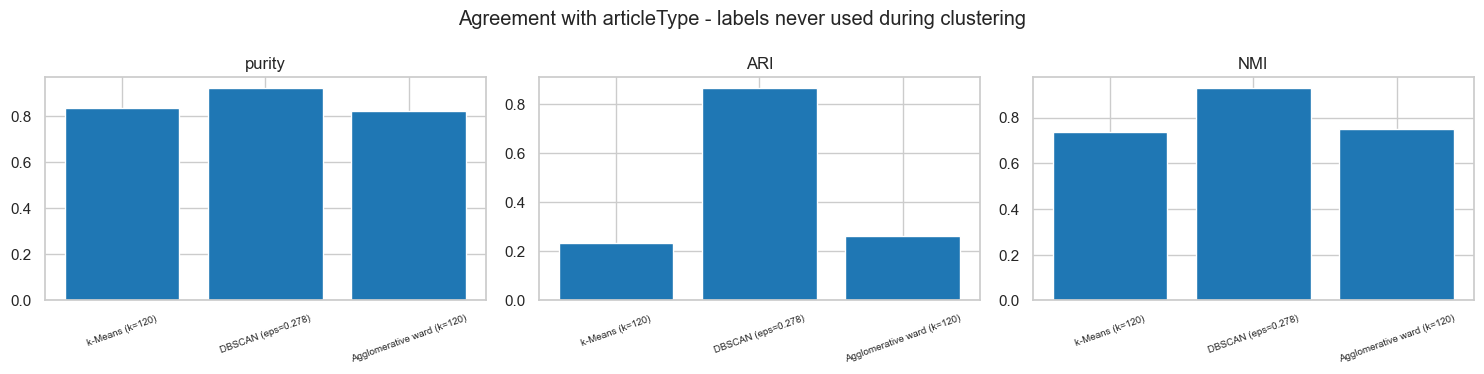

Caveat for the report: k-Means ran on all 32,837 points, DBSCAN on 8,000
and hierarchical on 4,000, because of their memory and time costs. Scores
are therefore indicative rather than a strict like-for-like ranking.


In [15]:
# ============================================
# CELL 15 - All three methods side by side
# ============================================

comparison = pd.DataFrame(results)
display(comparison)

# Bar only the rows that cover every point they were scored on. Plotting a
# 9%-coverage DBSCAN row beside a 100%-coverage k-Means row compares a method on
# its easiest tenth against another on everything, and DBSCAN "wins" purely
# because of what it threw away.
comparable = comparison[comparison["coverage %"] >= 99.9]

fig, axes = plt.subplots(1, 3, figsize=(15, 3.8))
for ax, metric in zip(axes, ["purity", "ARI", "NMI"]):
    ax.bar(comparable["method"], comparable[metric], color="tab:blue")
    ax.set_title(metric); ax.tick_params(axis="x", rotation=20, labelsize=7)
plt.suptitle("Agreement with articleType, full-coverage rows only "
             "- labels never used during clustering")
plt.tight_layout(); plt.show()

print("Two caveats, and the second one matters more than the first.")
print()
print("1. Sample size: k-Means ran on all 32,837 points, DBSCAN on 8,000 and")
print("   hierarchical on 4,000, because of their memory and time costs.")
print()
print("2. Coverage: DBSCAN leaves ~91% of points as noise, and its headline")
print("   purity/ARI are computed only on the ~9% it kept. Those are not")
print("   comparable with k-Means scored on every point, so the chart above uses")
print("   full-coverage rows only. The [noise as singletons] row shows the same")
print("   DBSCAN clustering scored the way a deployed router would have to use")
print("   it - every item assigned to something.")
comparison.to_csv(OUTPUT_DIR / "clustering_comparison.csv", index=False)

## 9. Putting the clusters to work: faster search

Exact search compares a query against all 32,837 vectors. With clusters, the query is compared
against the `k` centroids first, then only against the members of the nearest few — the standard
inverted-file index.

The trade-off is measurable: fewer clusters probed means fewer comparisons but a greater chance
of missing the true nearest neighbours. **Recall@10** here means the share of the exact search's
top 10 that the cluster-restricted search also returned.

exact search: 1.88 ms/query over 32,837 items
probe  1 clusters -> recall@10 0.783, compares 1.2% of the catalogue
probe  2 clusters -> recall@10 0.918, compares 2.2% of the catalogue
probe  3 clusters -> recall@10 0.963, compares 3.2% of the catalogue
probe  5 clusters -> recall@10 0.983, compares 5.1% of the catalogue
probe 10 clusters -> recall@10 0.991, compares 9.8% of the catalogue
probe 20 clusters -> recall@10 0.998, compares 19.1% of the catalogue


,clusters probed,recall@10,items compared,% of catalogue,ms/query
0,1,0.783,381,1.2,0.110
1,2,0.918,721,2.2,0.176
2,3,0.963,1051,3.2,0.242
3,5,0.983,1672,5.1,0.428
4,10,0.991,3228,9.8,1.068
5,20,0.998,6263,19.1,1.872


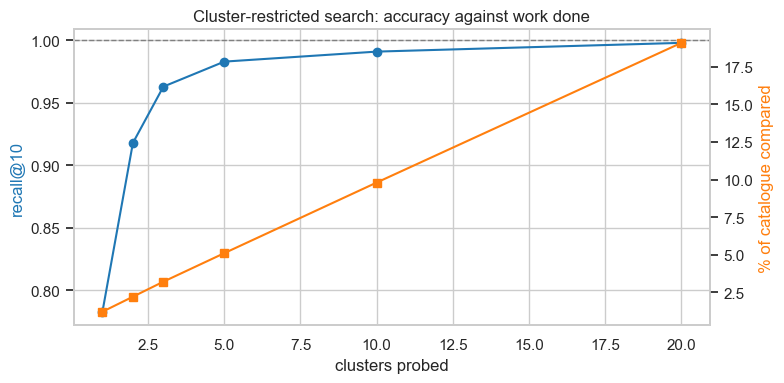

In [16]:
# ============================================
# CELL 16 - Cluster-accelerated retrieval
# ============================================

QUERIES = 500
query_idx = rng.choice(len(X), QUERIES, replace=False)
Q = X[query_idx]

started = time.time()
exact_scores = Q @ X.T
np.put_along_axis(exact_scores, query_idx[:, None], -2, axis=1)   # exclude self
exact_top = np.argsort(-exact_scores, axis=1)[:, :10]
exact_ms = (time.time() - started) / QUERIES * 1000
print(f"exact search: {exact_ms:.2f} ms/query over {len(X):,} items")

centroids = kmeans.cluster_centers_
members = {c: np.where(km_labels == c)[0] for c in range(K_CHOSEN)}

rows = []
for probes in [1, 2, 3, 5, 10, 20]:
    started = time.time()
    recalls, compared = [], []
    for row, q in enumerate(Q):
        nearest = np.argsort(-(centroids @ q))[:probes]
        candidates = np.concatenate([members[c] for c in nearest])
        candidates = candidates[candidates != query_idx[row]]
        if len(candidates) == 0:
            recalls.append(0.0); compared.append(0); continue
        scores = X[candidates] @ q
        top = candidates[np.argsort(-scores)[:10]]
        recalls.append(len(set(top) & set(exact_top[row])) / 10)
        compared.append(len(candidates))
    rows.append({"clusters probed": probes,
                 "recall@10": round(float(np.mean(recalls)), 3),
                 "items compared": int(np.mean(compared)),
                 "% of catalogue": round(np.mean(compared) / len(X) * 100, 1),
                 "ms/query": round((time.time() - started) / QUERIES * 1000, 3)})
    print(f"probe {probes:>2} clusters -> recall@10 {rows[-1]['recall@10']:.3f}, "
          f"compares {rows[-1]['% of catalogue']:.1f}% of the catalogue")

ivf = pd.DataFrame(rows)
display(ivf)

fig, ax1 = plt.subplots(figsize=(8, 4))
ax1.plot(ivf["clusters probed"], ivf["recall@10"], marker="o", color="tab:blue")
ax1.set_xlabel("clusters probed"); ax1.set_ylabel("recall@10", color="tab:blue")
ax1.axhline(1.0, ls="--", color="grey", lw=1)
ax2 = ax1.twinx()
ax2.plot(ivf["clusters probed"], ivf["% of catalogue"], marker="s", color="tab:orange")
ax2.set_ylabel("% of catalogue compared", color="tab:orange"); ax2.grid(False)
plt.title("Cluster-restricted search: accuracy against work done")
plt.tight_layout(); plt.show()

ivf.to_csv(OUTPUT_DIR / "cluster_search_tradeoff.csv", index=False)

## 10. Do the clusters survive a change of background?

Notebook 06 trained the encoder to ignore backgrounds. Clustering gives a way to test that
without any labels: take held-out items, composite them onto random backgrounds exactly as that
notebook did, and check whether each one still lands in the cluster its clean version belongs to.

A high agreement means the grouping reflects the garment rather than its surroundings.

In [ ]:
# ============================================
# CELL 17 - Cluster stability under background change
# ============================================

import sys
sys.path.insert(0, str(PROJECT_DIR))

CACHE = PROCESSED_DIR / "search_cache_60x80.npy"
MASKS = PROCESSED_DIR / "item_masks_60x80.npy"
ENCODER = ARTIFACT_DIR / MANIFEST.get("encoder_file", "task4_improved_encoder.pt")

if CACHE.exists() and MASKS.exists() and ENCODER.exists():
    import torch
    import torch.nn.functional as F
    from src.visual_search.search_engine import ImprovedEncoder

    IMAGES = np.load(CACHE, mmap_mode="r")
    ITEM_MASKS = np.load(MASKS, mmap_mode="r")
    full_meta = pd.read_csv(PROCESSED_DIR / "clean_train_metadata.csv")

    # positions in the full gallery for the catalogue rows we clustered
    id_to_full = {i: p for p, i in enumerate(full_meta["id"].to_numpy())}
    catalogue_pos = np.array([id_to_full[i] for i in meta["id"].to_numpy()])

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    checkpoint = torch.load(ENCODER, map_location=device)
    encoder = ImprovedEncoder(checkpoint["embedding_dim"],
                              n_types=checkpoint.get("n_types", 0),
                              n_colours=checkpoint.get("n_colours", 0))
    encoder.load_state_dict(checkpoint["state_dict"]); encoder.to(device).eval()
    mean = torch.tensor(checkpoint["channel_mean"]).view(1, 3, 1, 1)
    std = torch.tensor(checkpoint["channel_std"]).view(1, 3, 1, 1)

    # Imported, not re-implemented. This cell used to define its own
    # three-family background generator and its own composite(), while the
    # markdown above claimed the items were composited "exactly as that notebook
    # did". They were not: notebook 06 uses five families and a wider scale
    # range, so the agreement figure below was measured against an easier
    # distribution than the encoder is trained and benchmarked on.
    from src.data.synthetic_backgrounds import composite, make_backgrounds

    STABILITY_BACKGROUNDS = make_backgrounds(
        200, shape=(80, 60, 3), seed=99, source_images=IMAGES)

    SAMPLE = 1500
    picked = rng.choice(len(meta), SAMPLE, replace=False)
    generator = np.random.default_rng(99)
    hard = np.stack([composite(np.asarray(IMAGES[catalogue_pos[p]]),
                               np.asarray(ITEM_MASKS[catalogue_pos[p]]),
                               STABILITY_BACKGROUNDS[
                                   generator.integers(len(STABILITY_BACKGROUNDS))],
                               generator)
                     for p in picked])

    with torch.no_grad():
        batch = torch.from_numpy(hard.astype(np.float32).transpose(0, 3, 1, 2) / 255.0)
        batch = ((batch - mean) / std).to(device)
        vectors = encoder.embed(batch)
        vectors = F.normalize(vectors + encoder.embed(torch.flip(batch, dims=[3])), p=2, dim=1)
        hard_vectors = vectors.cpu().numpy()

    hard_clusters = np.argmin(
        ((hard_vectors[:, None, :] - centroids[None, :, :]) ** 2).sum(axis=2), axis=1)
    agreement = (hard_clusters == km_labels[picked]).mean()

    print(f"Items tested                          : {SAMPLE}")
    print(f"Still assigned to the same cluster    : {agreement * 100:.1f}%")
    same_type = np.array([clusters.set_index('cluster')['dominant articleType']
                          .get(c, '') == article[p]
                          for c, p in zip(hard_clusters, picked)])
    print(f"Landed in a cluster whose dominant    : {same_type.mean() * 100:.1f}%")
    print(f"  type matches the item's own type")

    fig, axes = plt.subplots(2, 10, figsize=(15, 3.6))
    for column in range(10):
        axes[0][column].imshow(np.asarray(IMAGES[catalogue_pos[picked[column]]]))
        axes[1][column].imshow(hard[column])
        for row in range(2):
            axes[row][column].axis("off")
        same = hard_clusters[column] == km_labels[picked[column]]
        axes[1][column].set_title("same" if same else "moved", fontsize=6,
                                  color="tab:green" if same else "tab:red")
    plt.suptitle("Original (top) and background-composited (bottom) - did the cluster hold?")
    plt.tight_layout(); plt.show()
else:
    print("Skipped - needs search_cache_60x80.npy, item_masks_60x80.npy and the encoder.")
    print("Run notebook 08 first to produce the mask cache.")

## 11. Save results

In [18]:
# ============================================
# CELL 18 - Persist the clustering
# ============================================

assignments = meta[["id", "articleType", "baseColour"]].copy()
assignments["kmeans_cluster"] = km_labels
assignments.to_csv(OUTPUT_DIR / "cluster_assignments.csv", index=False)

clusters.to_csv(OUTPUT_DIR / "cluster_summary.csv", index=False)
sweep.to_csv(OUTPUT_DIR / "kmeans_k_sweep.csv", index=False)
np.save(OUTPUT_DIR / "kmeans_centroids.npy", centroids)

summary = {
    "embeddings_from": MANIFEST["best_method"],
    "n_items": int(len(X)),
    "k_chosen": int(K_CHOSEN),
    "best_silhouette_k": int(best_k),
    "kmeans_SD": round(float(kmeans.inertia_), 2),
    "kmeans_iterations": int(kmeans.n_iter_),
    "mean_purity": round(float(clusters["purity"].mean()), 3),
    "methods_compared": [row["method"] for row in results],
}
with open(OUTPUT_DIR / "clustering_summary.json", "w") as handle:
    json.dump(summary, handle, indent=2)

print("Saved to", OUTPUT_DIR)
for name in ["cluster_assignments.csv", "cluster_summary.csv", "kmeans_k_sweep.csv",
             "kmeans_centroids.npy", "clustering_comparison.csv",
             "cluster_search_tradeoff.csv", "clustering_summary.json"]:
    print("  ", name)

Saved to c:\Users\LEGION\Documents\jupyter_notebook\Fashion-Intelligence-System\outputs
   cluster_assignments.csv
   cluster_summary.csv
   kmeans_k_sweep.csv
   kmeans_centroids.npy
   clustering_comparison.csv
   cluster_search_tradeoff.csv
   clustering_summary.json


## 12. The clustering as a usable model

Everything above analyses. This section turns it into something that can be pointed at a
photograph — `src/visual_search/cluster_engine.py`.

The saved model is small: **the centroids plus the cluster-to-type mapping**. For a new image it
embeds, finds the nearest centroid, and reports which cluster the item belongs to, what that
cluster mostly contains, and how confident the assignment is. `search()` then ranks only that
cluster's members, which is the accelerated retrieval measured in Cell 16.

Confidence comes from the **margin** — the gap between the nearest and second-nearest centroid.
A large margin means the item sits clearly inside one group; a small one means it fell between
two, which is the honest signal for "no confident match".

In [19]:
# ============================================
# CELL 19 - Load the clustering model
# ============================================

import sys
sys.path.insert(0, str(PROJECT_DIR))
from src.visual_search.cluster_engine import ClusterEngine

engine = ClusterEngine.load(PROJECT_DIR)
print("clusters      :", len(engine.centroids))
print("catalogue     :", f"{len(engine.metadata):,} items")
print("embedding dim :", engine.centroids.shape[1])
print("device        :", engine.device)

clusters      : 120
catalogue     : 32,837 items
embedding dim : 128
device        : cuda


In [20]:
# ============================================
# CELL 20 - Test it on the user images folder
# ============================================

INPUT_DIR = PROJECT_DIR / "A2_FashionDataset" / "input_images"
SUFFIXES = {".jpg", ".jpeg", ".png", ".webp", ".avif", ".bmp"}

if INPUT_DIR.exists():
    test_paths = sorted(p for p in INPUT_DIR.iterdir()
                        if p.is_file() and p.suffix.lower() in SUFFIXES)
    print(f"testing {len(test_paths)} images\n")

    rows = []
    for path in test_paths:
        prediction = engine.predict(path)
        best = prediction["best"]
        rows.append({
            "file": path.name[:32],
            "cluster": best["cluster"],
            "cluster contains": best["dominant_type"],
            "purity": best["purity"],
            "distance": best["distance"],
            "margin": prediction["margin"],
            "confident": prediction["confident"],
        })
    predictions = pd.DataFrame(rows).sort_values("margin", ascending=False)
    display(predictions)
    print(f"confident assignments: {int(predictions['confident'].sum())}/{len(predictions)}")
else:
    print("No input_images folder - skipping.")
    test_paths = []

testing 19 images



,file,cluster,cluster contains,purity,distance,margin,confident
18,The_dress_blueblackwhitegold.jpg,96,Handbags,0.412,0.7734,0.1756,True
9,giay-local-brand-viet-nam_b14084,8,Cufflinks,1.000,0.9444,0.1410,True
13,images (4).jpg,97,Bra,0.967,0.8273,0.1075,True
16,images.jpg,57,Scarves,0.766,0.8784,0.1031,True
17,mygoods_34_475601_3x4-ezgif.com-,37,Sarees,0.962,0.8752,0.0880,True
7,Collier_ruban_or_vermeil_2.webp,24,Nail Polish,0.110,0.9487,0.0773,True
12,images (3).jpg,44,Bra,0.964,0.9241,0.0704,True
15,images (6).jpg,44,Bra,0.964,0.8089,0.0671,True
10,images (1).jpg,64,Clutches,0.774,0.7732,0.0536,True
11,images (2).jpg,38,Shorts,0.949,0.9011,0.0409,False


confident assignments: 9/19


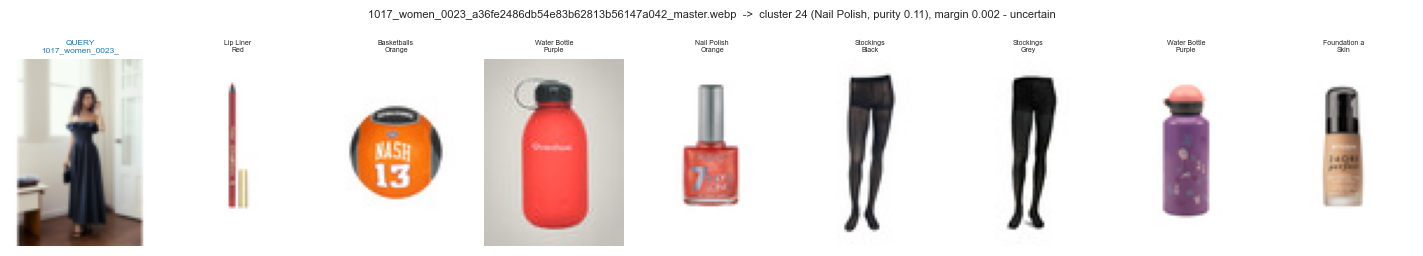

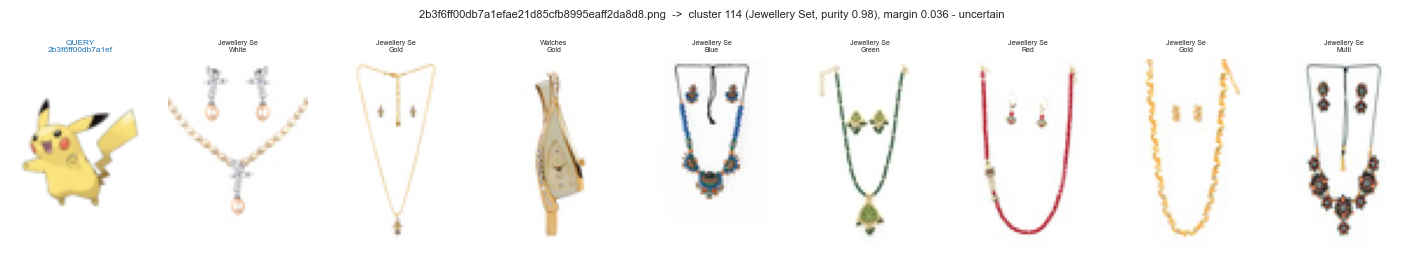

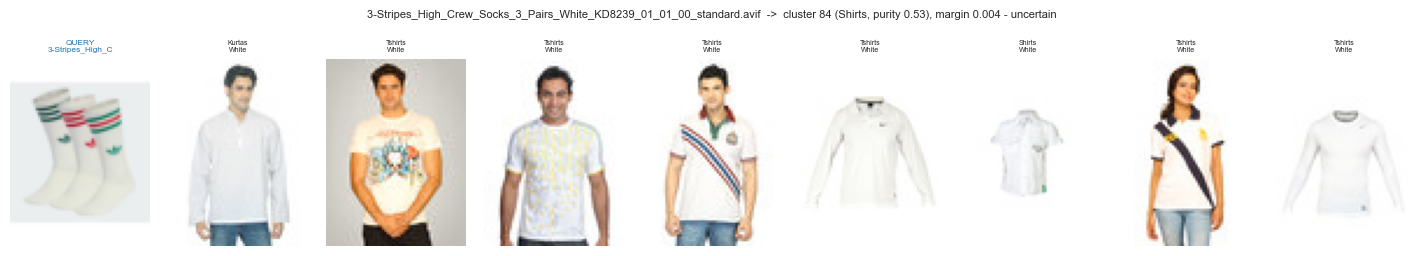

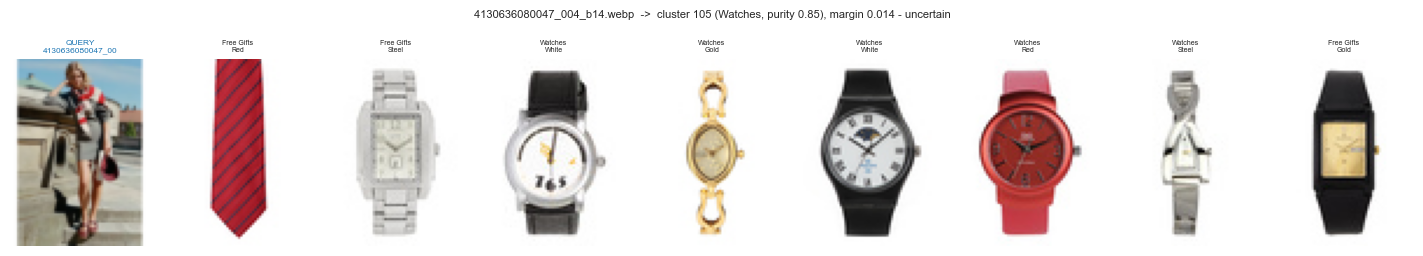

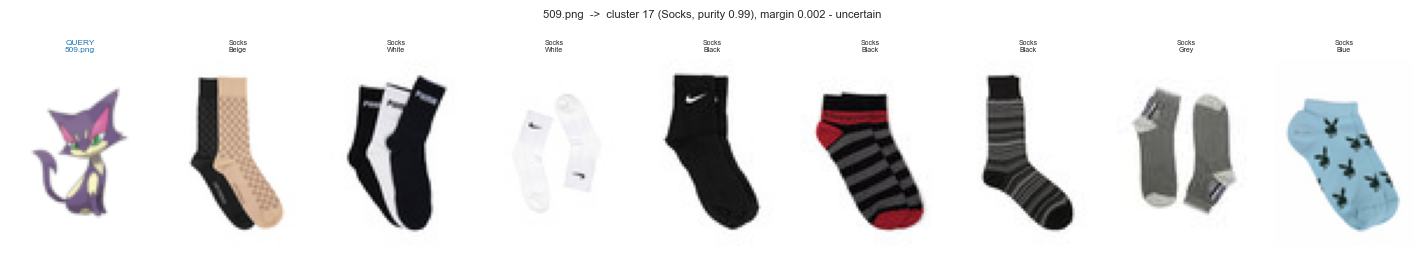

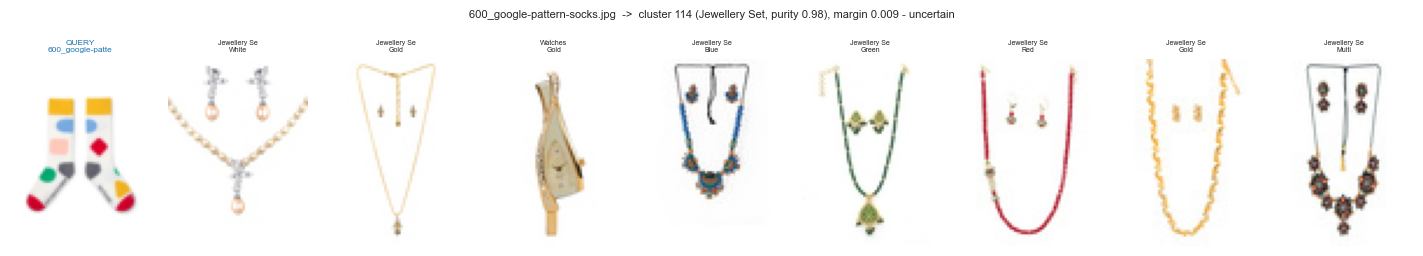

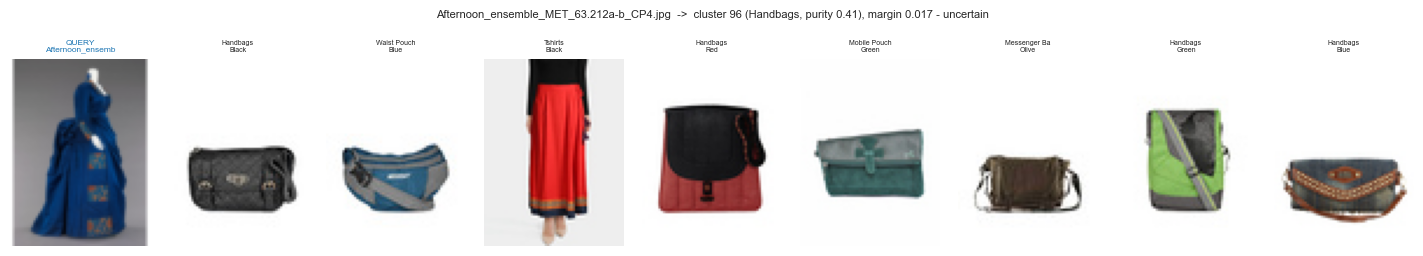

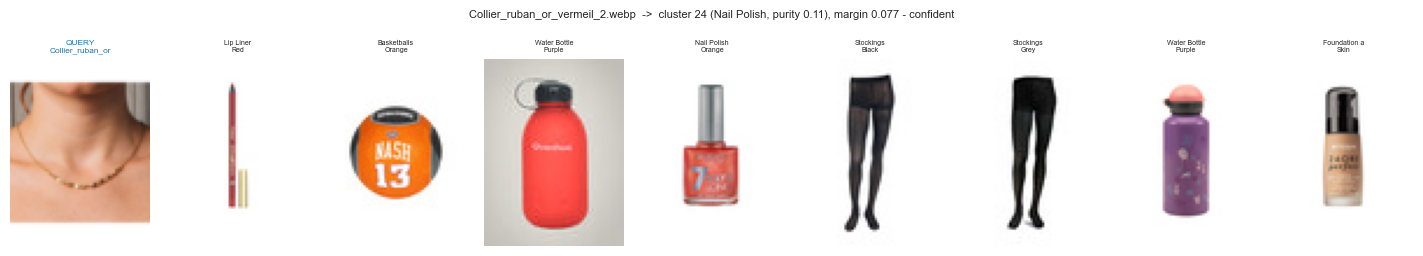

In [21]:
# ============================================
# CELL 21 - Show each query beside its cluster
# ============================================

from src.visual_search.search_engine import load_user_image as prep

for path in test_paths[:8]:
    prediction = engine.predict(path)
    best = prediction["best"]
    members = engine.cluster_members(best["cluster"], n=8)

    fig, axes = plt.subplots(1, len(members) + 1, figsize=(1.6 * (len(members) + 1), 2.7))
    axes[0].imshow(prep(path, engine.size)); axes[0].axis("off")
    axes[0].set_title(f"QUERY\n{path.name[:16]}", fontsize=6, color="tab:blue")
    for ax, (_, row) in zip(axes[1:], members.iterrows()):
        ax.imshow(load_thumb(row["image_path"])); ax.axis("off")
        ax.set_title(f"{row['articleType'][:12]}\n{row['baseColour'][:10]}", fontsize=5)

    verdict = "confident" if prediction["confident"] else "uncertain"
    fig.suptitle(f"{path.name}  ->  cluster {best['cluster']} "
                 f"({best['dominant_type']}, purity {best['purity']:.2f}), "
                 f"margin {prediction['margin']:.3f} - {verdict}", fontsize=8)
    plt.tight_layout(); plt.show()

In [22]:
# ============================================
# CELL 22 - Cluster-accelerated search on a real upload
# ============================================

if test_paths:
    query = test_paths[0]
    for probes in [1, 3, 10]:
        results, compared = engine.search(query, k=5, probes=probes)
        print(f"\nprobing {probes} cluster(s) - compared {compared:,} of "
              f"{len(engine.metadata):,} items ({compared / len(engine.metadata) * 100:.1f}%)")
        display(results[["rank", "articleType", "baseColour", "similarity", "cluster"]])


probing 1 cluster(s) - compared 154 of 32,837 items (0.5%)


,rank,articleType,baseColour,similarity,cluster
0,1,Watches,Gold,0.5570,24
1,2,Headband,White,0.4091,24
2,3,Concealer,Skin,0.3086,24
3,4,Shoe Accessories,White,0.3029,24
4,5,Concealer,Beige,0.2938,24



probing 3 cluster(s) - compared 640 of 32,837 items (1.9%)


,rank,articleType,baseColour,similarity,cluster
0,1,Perfume and Body Mist,Red,0.5588,53
1,2,Watches,Gold,0.5570,24
2,3,Perfume and Body Mist,Pink,0.5467,53
3,4,Perfume and Body Mist,Copper,0.5221,53
4,5,Fragrance Gift Set,White,0.5039,72



probing 10 cluster(s) - compared 2,047 of 32,837 items (6.2%)


,rank,articleType,baseColour,similarity,cluster
0,1,Perfume and Body Mist,Red,0.5588,53
1,2,Watches,Gold,0.5570,24
2,3,Perfume and Body Mist,Pink,0.5467,53
3,4,Perfume and Body Mist,Copper,0.5221,53
4,5,Socks,White,0.5165,17


## 13. Testing on the assignment's own test images

`input_images` holds photographs from the open web — busy backgrounds, worn garments, some not
clothing at all. The assignment's `images_test` folder is the opposite: 5,829 catalogue-style
shots in exactly the format the encoder was trained on, and never seen during training.

Running both through the same model separates two questions that are easy to confuse:

* **Is the model any good?** Answered by the clean test images.
* **Does it survive a real upload?** Answered by `input_images`.

If the model is confident on `images_test` and uncertain on `input_images`, the problem is the
domain gap rather than the model.

**On labels:** `images_test` is the held-out set you must predict for, so no labels are used
here — only the images. Cluster assignments are reported as predictions, never scored.

In [23]:
# ============================================
# CELL 23 - Sample the assignment test images
# ============================================

TEST_META = PROCESSED_DIR / "prediction_metadata.csv"
TEST_DIR = PROJECT_DIR / "A2_FashionDataset" / "FashionDataset" / "test" / "images_test"

if TEST_META.exists():
    test_meta = pd.read_csv(TEST_META)
    print(f"assignment test images: {len(test_meta):,}")
    label_cols = [c for c in ["gender", "usage", "articleType", "season"]
                  if c in test_meta.columns]
    print("labels available:", {c: int(test_meta[c].notna().sum()) for c in label_cols})
    print("-> all empty, as expected: these are the items to be predicted.\n")

    N_TEST = 12
    sample_test = test_meta.sample(N_TEST, random_state=RANDOM_STATE)
    test_image_paths = [Path(p) for p in sample_test["image_path"]]

    # fall back to the folder if the stored absolute paths do not resolve
    if not test_image_paths[0].exists() and TEST_DIR.exists():
        test_image_paths = [TEST_DIR / f"{i}.jpg" for i in sample_test["id"]]
    print("resolved:", sum(p.exists() for p in test_image_paths), "/", len(test_image_paths))
else:
    test_image_paths, sample_test = [], None
    print("prediction_metadata.csv not found - run 01_eda.ipynb first.")

assignment test images: 5,829
labels available: {'gender': 0, 'usage': 0, 'articleType': 0, 'season': 0}
-> all empty, as expected: these are the items to be predicted.

resolved: 12 / 12


,id,cluster,cluster contains,purity,distance,margin,confident
3,52862,31,Earrings,0.992,0.4842,0.5576,True
1,58724,34,Tshirts,0.958,0.4551,0.1750,True
4,53777,95,Sports Shoes,0.840,0.1708,0.1667,True
9,58586,103,Necklace and Chains,1.000,0.6559,0.1661,True
6,57200,117,Dresses,0.713,0.5526,0.1228,True
2,53680,51,Handbags,0.997,0.5652,0.1203,True
10,59091,44,Bra,0.964,0.4455,0.1203,True
7,59883,75,Tops,0.682,0.7154,0.0960,True
0,59267,42,Watches,0.993,0.5066,0.0761,True
11,53815,6,Kurtas,0.895,0.6227,0.0199,False


confident: 9/12


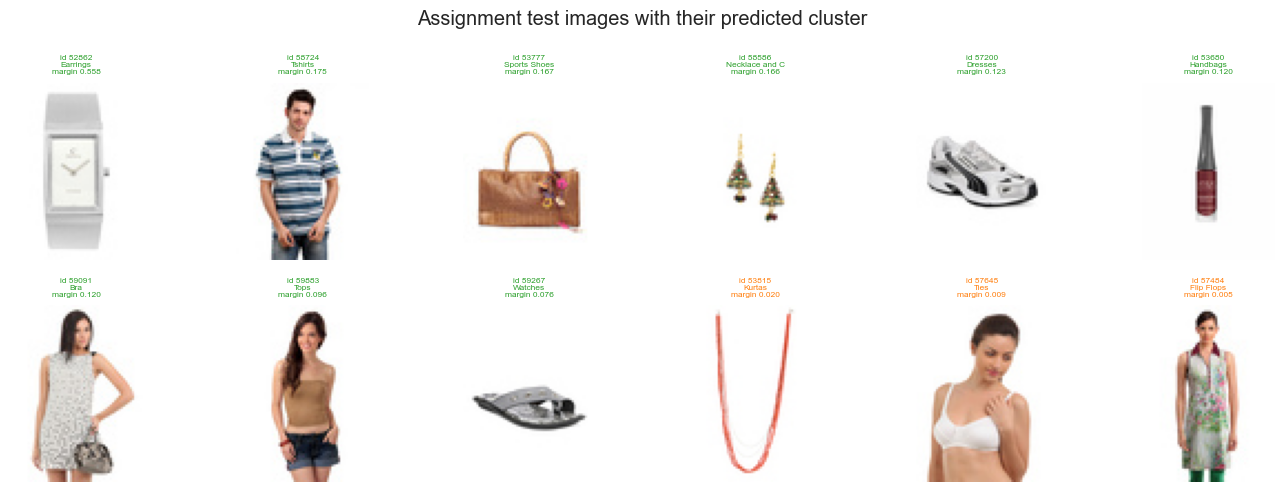

In [24]:
# ============================================
# CELL 24 - Cluster the test images
# ============================================

if test_image_paths:
    rows = []
    for path, item_id in zip(test_image_paths, sample_test["id"]):
        prediction = engine.predict(path)
        best = prediction["best"]
        rows.append({
            "id": item_id,
            "cluster": best["cluster"],
            "cluster contains": best["dominant_type"],
            "purity": best["purity"],
            "distance": best["distance"],
            "margin": prediction["margin"],
            "confident": prediction["confident"],
        })
    test_predictions = pd.DataFrame(rows).sort_values("margin", ascending=False)
    display(test_predictions)
    print(f"confident: {int(test_predictions['confident'].sum())}/{len(test_predictions)}")

    fig, axes = plt.subplots(2, 6, figsize=(14, 5))
    for ax, (path, (_, row)) in zip(axes.ravel(),
                                    zip(test_image_paths, test_predictions.iterrows())):
        ax.imshow(prep(path, engine.size)); ax.axis("off")
        ax.set_title(f"id {row['id']}\n{row['cluster contains'][:14]}\n"
                     f"margin {row['margin']:.3f}", fontsize=6,
                     color="tab:green" if row["confident"] else "tab:orange")
    plt.suptitle("Assignment test images with their predicted cluster")
    plt.tight_layout(); plt.show()

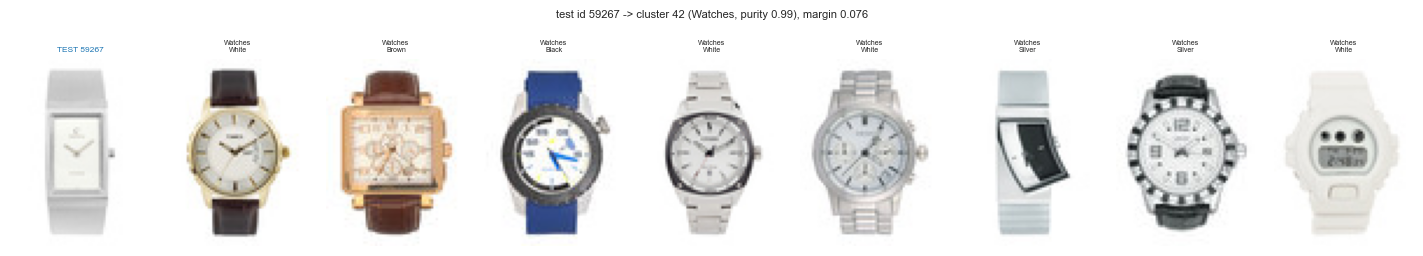

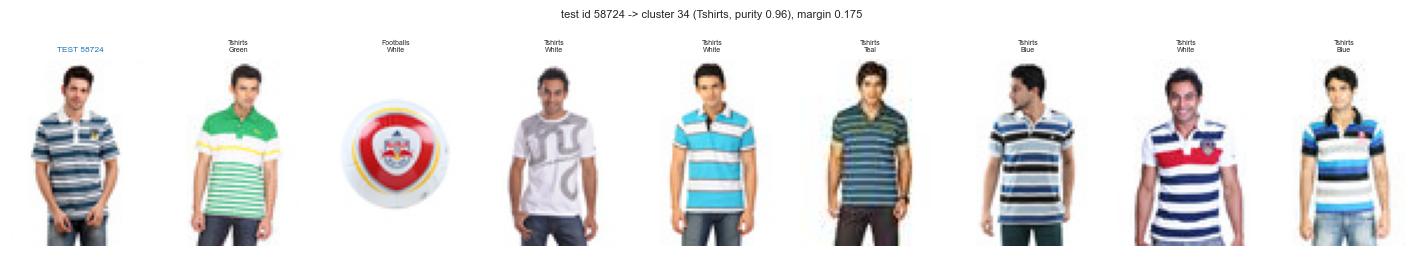

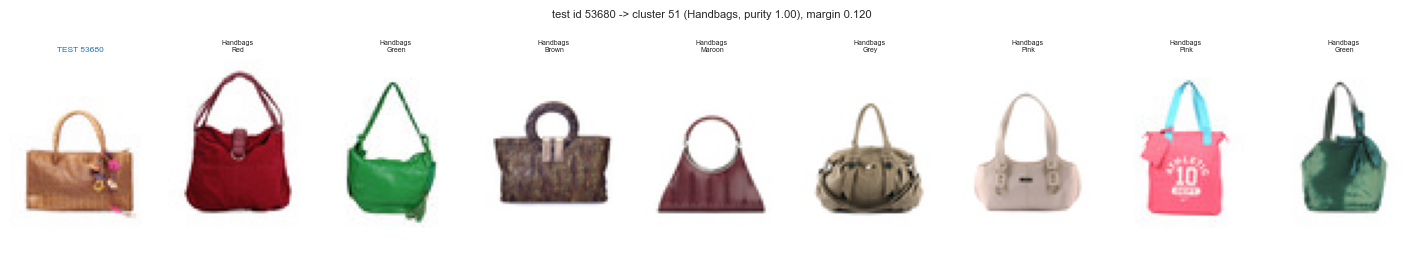

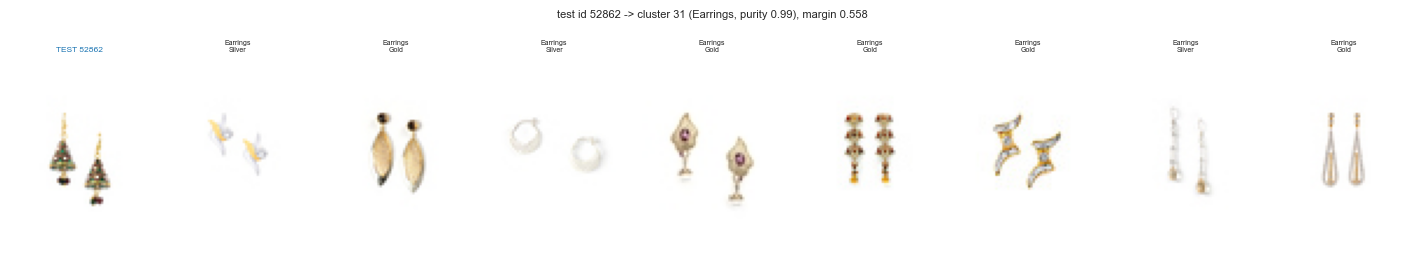

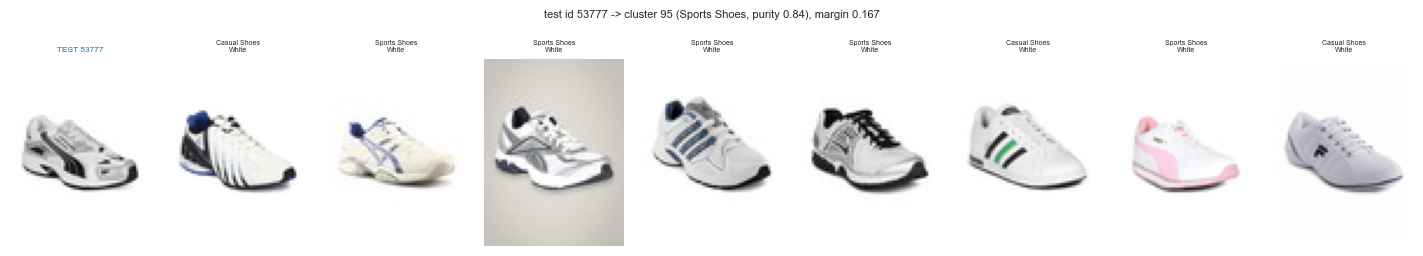

In [25]:
# ============================================
# CELL 25 - A test image beside its cluster
# ============================================

if test_image_paths:
    for path, item_id in list(zip(test_image_paths, sample_test["id"]))[:5]:
        prediction = engine.predict(path)
        best = prediction["best"]
        members = engine.cluster_members(best["cluster"], n=8)

        fig, axes = plt.subplots(1, len(members) + 1,
                                 figsize=(1.6 * (len(members) + 1), 2.7))
        axes[0].imshow(prep(path, engine.size)); axes[0].axis("off")
        axes[0].set_title(f"TEST {item_id}", fontsize=6, color="tab:blue")
        for ax, (_, row) in zip(axes[1:], members.iterrows()):
            ax.imshow(load_thumb(row["image_path"])); ax.axis("off")
            ax.set_title(f"{row['articleType'][:12]}\n{row['baseColour'][:10]}", fontsize=5)
        fig.suptitle(f"test id {item_id} -> cluster {best['cluster']} "
                     f"({best['dominant_type']}, purity {best['purity']:.2f}), "
                     f"margin {prediction['margin']:.3f}", fontsize=8)
        plt.tight_layout(); plt.show()

,source,n,mean margin,median margin,confident %
0,images_test (catalogue style),60,0.1603,0.0958,75.0
1,input_images (web photos),19,0.0553,0.0409,47.4


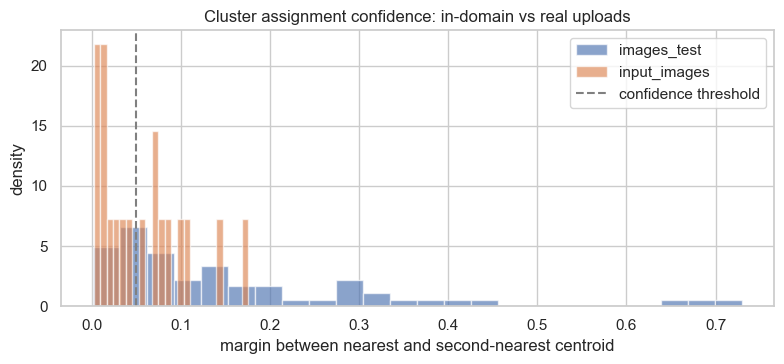

A clear gap here means the model is sound but the uploads are out of
distribution - which is a data problem, not a modelling one.


In [26]:
# ============================================
# CELL 26 - Clean test images vs messy user uploads
# ============================================

if test_image_paths and len(test_paths):
    N_COMPARE = 60
    compare_test = test_meta.sample(min(N_COMPARE, len(test_meta)),
                                    random_state=RANDOM_STATE + 1)
    compare_paths = [Path(p) for p in compare_test["image_path"]]
    if not compare_paths[0].exists():
        compare_paths = [TEST_DIR / f"{i}.jpg" for i in compare_test["id"]]

    def margins_for(paths):
        out = []
        for path in paths:
            try:
                out.append(engine.predict(path)["margin"])
            except Exception:
                pass
        return np.array(out)

    test_margins = margins_for(compare_paths)
    user_margins = margins_for(test_paths)

    comparison_rows = pd.DataFrame([
        {"source": "images_test (catalogue style)", "n": len(test_margins),
         "mean margin": round(float(test_margins.mean()), 4),
         "median margin": round(float(np.median(test_margins)), 4),
         "confident %": round(float((test_margins > 0.05).mean() * 100), 1)},
        {"source": "input_images (web photos)", "n": len(user_margins),
         "mean margin": round(float(user_margins.mean()), 4),
         "median margin": round(float(np.median(user_margins)), 4),
         "confident %": round(float((user_margins > 0.05).mean() * 100), 1)},
    ])
    display(comparison_rows)

    plt.figure(figsize=(8, 3.8))
    plt.hist(test_margins, bins=24, alpha=0.65, label="images_test", density=True)
    plt.hist(user_margins, bins=24, alpha=0.65, label="input_images", density=True)
    plt.axvline(0.05, ls="--", color="grey", label="confidence threshold")
    plt.xlabel("margin between nearest and second-nearest centroid")
    plt.ylabel("density"); plt.legend()
    plt.title("Cluster assignment confidence: in-domain vs real uploads")
    plt.tight_layout(); plt.show()

    comparison_rows.to_csv(OUTPUT_DIR / "cluster_domain_comparison.csv", index=False)
    print("A clear gap here means the model is sound but the uploads are out of")
    print("distribution - which is a data problem, not a modelling one.")
else:
    print("Need both images_test and input_images for this comparison.")

In [27]:
# ============================================
# CELL 27 - Save the model bundle
# ============================================

bundle = {
    "kind": "kmeans-over-cnn-embeddings",
    "encoder": MANIFEST.get("encoder_file", "task4_improved_encoder.pt"),
    "embeddings_from": MANIFEST["best_method"],
    "k": int(K_CHOSEN),
    "embedding_dim": int(X.shape[1]),
    "catalogue_size": int(len(X)),
    "centroids_file": "kmeans_centroids.npy",
    "assignments_file": "cluster_assignments.csv",
    "summary_file": "cluster_summary.csv",
    "mean_purity": round(float(clusters["purity"].mean()), 3),
    "recommended_probes": 3,
    "recall_at_10_with_3_probes": float(
        ivf.loc[ivf["clusters probed"] == 3, "recall@10"].iloc[0]),
}
with open(OUTPUT_DIR / "cluster_model.json", "w") as handle:
    json.dump(bundle, handle, indent=2)

print(json.dumps(bundle, indent=2))
print("\nLoad it anywhere with:")
print("    from src.visual_search.cluster_engine import ClusterEngine")
print("    engine = ClusterEngine.load()")
print("    engine.predict('photo.jpg')")

{
  "kind": "kmeans-over-cnn-embeddings",
  "encoder": "task4_improved_encoder.pt",
  "embeddings_from": "Improved+TTA+bgaug",
  "k": 120,
  "embedding_dim": 128,
  "catalogue_size": 32837,
  "centroids_file": "kmeans_centroids.npy",
  "assignments_file": "cluster_assignments.csv",
  "summary_file": "cluster_summary.csv",
  "mean_purity": 0.806,
  "recommended_probes": 3,
  "recall_at_10_with_3_probes": 0.963
}

Load it anywhere with:
    from src.visual_search.cluster_engine import ClusterEngine
    engine = ClusterEngine.load()
    engine.predict('photo.jpg')


### For the report

**Choosing k.** SD falls monotonically, exactly as the notes state, so the elbow and the
silhouette score do the work. Quote both curves and say which you followed — they rarely agree
exactly, and explaining the disagreement is worth more than pretending it did not happen.

**Centroid versus medoid.** Centroids are averages that correspond to no real product; the
medoid is the nearest actual item and is what a catalogue interface would display. Cell 6 shows
the medoids.

**Validation without labels.** The clustering never saw `articleType`; purity, ARI and NMI are
computed afterwards. That makes them an honest measure of whether the encoder learned the
catalogue's structure, rather than a fit to it.

**Why k-Means is not enough.** The two-moons figure shows the spherical-cluster limitation from
§5 directly, and DBSCAN recovers what k-Means cannot. On the real embeddings DBSCAN behaves
differently again — report the noise fraction, since a large one says the space is fairly
uniform rather than made of dense islands.

**Linkage matters.** Single linkage chains clusters together through thin bridges and typically
collapses most of the data into one group; ward behaves closest to k-Means. The comparison in
Cell 14 makes that concrete.

**A practical payoff.** Cell 16 turns the clusters into a faster search and quantifies the
accuracy lost. That is the strongest argument for including unsupervised learning in a
retrieval system at all.

**Honest caveats.** k-Means used all 32,837 vectors, DBSCAN 8,000 and hierarchical 4,000,
because the latter two scale quadratically. State that before comparing their scores.